In [ ]:
# Libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load dataset
# Read the entire text as a string
with open('ikea_kommun_data.txt', 'r', encoding='ISO-8859-1') as f:
    df = f.read()
print(df)

"Kommun_code"	"Year"	"Kommun_name"	"Revenue"	"Employee"	"Population"	"Population_University"	"Percent_University"	"Productivity"	"SalesIndex"	"Infrast"	"Border"
"2583"	"2010"	"Haparanda"	"1078"	"276"	"10059"	"719"	"0.07147828"	"195.74174"	"111.075774"	"0"	"1"
"880"	"2010"	"Kalmar"	"3790"	"1621"	"62815"	"8716"	"0.13875667"	"117.17365"	"390.516869"	"0"	"0"
"1780"	"2010"	"Karlstad"	"4560"	"1910"	"85753"	"13308"	"0.15518991"	"119.64794"	"469.856708"	"0"	"0"
"114"	"2010"	"Upplands Väsby"	"1366"	"708"	"39289"	"4419"	"0.11247423"	"96.69215"	"140.750935"	"0"	"0"
"115"	"2010"	"Vallentuna"	"171"	"99"	"30114"	"3843"	"0.12761506"	"86.56347"	"17.619627"	"0"	"0"
"117"	"2010"	"Österåker"	"563"	"314"	"39521"	"5011"	"0.12679335"	"89.85712"	"58.010817"	"0"	"0"
"120"	"2010"	"Värmdö"	"920"	"454"	"38301"	"4720"	"0.12323438"	"101.55604"	"94.795652"	"0"	"0"
"123"	"2010"	"Järfälla"	"5119"	"2001"	"66211"	"9009"	"0.13606500"	"128.20702"	"527.455371"	"0"	"0"
"125"	"2010"	"Ekerö"	"144"	"116"	"25410"	"3893"	"0.153

In [4]:
df = pd.read_csv('ikea_kommun_data.txt', sep='\t', encoding='ISO-8859-1')

In [6]:
# Display basic information about the dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Kommun_code            207 non-null    int64  
 1   Year                   207 non-null    int64  
 2   Kommun_name            207 non-null    object 
 3   Revenue                207 non-null    int64  
 4   Employee               207 non-null    int64  
 5   Population             207 non-null    int64  
 6   Population_University  207 non-null    int64  
 7   Percent_University     207 non-null    float64
 8   Productivity           207 non-null    float64
 9   SalesIndex             207 non-null    float64
 10  Infrast                207 non-null    int64  
 11  Border                 207 non-null    int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 19.5+ KB
None


Check first few rows to understand the data

In [7]:
print("\nFirst 3 rows:")
print(df.head(3))


First 3 rows:
   Kommun_code  Year Kommun_name  Revenue  Employee  Population  \
0         2583  2010   Haparanda     1078       276       10059   
1          880  2010      Kalmar     3790      1621       62815   
2         1780  2010    Karlstad     4560      1910       85753   

   Population_University  Percent_University  Productivity  SalesIndex  \
0                    719            0.071478     195.74174  111.075774   
1                   8716            0.138757     117.17365  390.516869   
2                  13308            0.155190     119.64794  469.856708   

   Infrast  Border  
0        0       1  
1        0       0  
2        0       0  


1. Clean the dataset - check the data types, exclude the categorical data/textual

Remove categorical/textual columns

In [8]:
columns_to_remove = ['Kommun_name', 'Kommun_code']  # Municipality names and codes
df_clean = df.drop(columns=columns_to_remove)
print(f"\nAfter removing categorical columns:")
print(f"Shape: {df_clean.shape}")
print(f"Remaining columns: {list(df_clean.columns)}")


After removing categorical columns:
Shape: (207, 10)
Remaining columns: ['Year', 'Revenue', 'Employee', 'Population', 'Population_University', 'Percent_University', 'Productivity', 'SalesIndex', 'Infrast', 'Border']


In [9]:
# Convert all columns to numeric (in case any are still text) so its ready for PCA
for col in df_clean.columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

No NAs should be seen

In [10]:
# Check for missing values
print(f"\nMissing values:")
print(df_clean.isnull().sum())


Missing values:
Year                     0
Revenue                  0
Employee                 0
Population               0
Population_University    0
Percent_University       0
Productivity             0
SalesIndex               0
Infrast                  0
Border                   0
dtype: int64


I want to be sure what I am dealing with so I check the data types again before PCA

In [11]:
# Chceking for the final data types
print(f"\nFinal data types:")
print(df_clean.dtypes)


Final data types:
Year                       int64
Revenue                    int64
Employee                   int64
Population                 int64
Population_University      int64
Percent_University       float64
Productivity             float64
SalesIndex               float64
Infrast                    int64
Border                     int64
dtype: object


Univariate Analysis - To understand the data

In [12]:
# Basic statistics
print(f"\nBasic statistics:")
print(df_clean.describe())


Basic statistics:
         Year       Revenue      Employee     Population  \
count   207.0    207.000000    207.000000     207.000000   
mean   2010.0   1031.801932    523.038647   34543.396135   
std       0.0   2694.889549   1463.194427   66882.499740   
min    2010.0     11.000000      2.000000    3672.000000   
25%    2010.0    110.000000     64.500000   10785.500000   
50%    2010.0    252.000000    142.000000   16515.000000   
75%    2010.0    825.500000    435.000000   37922.000000   
max    2010.0  32897.000000  18795.000000  847073.000000   

       Population_University  Percent_University  Productivity   SalesIndex  \
count             207.000000          207.000000    207.000000   207.000000   
mean             4660.106280            0.097461     91.454002   106.315583   
std             14403.495784            0.040760     27.960867   277.678055   
min               174.000000            0.046142     19.898880     1.133426   
25%               788.500000            0.069

In [13]:
print("Dataset for PCA:")
print(f"Shape: {df_clean.shape}")
print(f"Columns: {list(df_clean.columns)}")

Dataset for PCA:
Shape: (207, 10)
Columns: ['Year', 'Revenue', 'Employee', 'Population', 'Population_University', 'Percent_University', 'Productivity', 'SalesIndex', 'Infrast', 'Border']


2. Perform PCA for dimensionality reduction (probably explain 90-95% of the total variance) – normalise/scale the data

PCA works on numeric alone so evethough I have checked for NAs I am still dropping any rows with missing NAs just to becareful. 

In [14]:
# Remove any rows with missing values (PCA can't handle NAs)
df_pca = df_clean.dropna()
print(f"After removing missing values: {df_pca.shape}")

After removing missing values: (207, 10)


Still same form what I know the dataframe to be so it is good. 

I follow these steps to Scale/Normalise my dataset for a clean flow.

In [15]:
# Step 1: Scale/Normalize the data
print("\n" + "="*50)
print("STEP 1: SCALING THE DATA")
print("="*50)


STEP 1: SCALING THE DATA


In [16]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_pca)

Data before Scaling

In [17]:
print("Original data ranges:")
for i, col in enumerate(df_pca.columns):
    print(f"{col}: {df_pca[col].min():.2f} to {df_pca[col].max():.2f}")

Original data ranges:
Year: 2010.00 to 2010.00
Revenue: 11.00 to 32897.00
Employee: 2.00 to 18795.00
Population: 3672.00 to 847073.00
Population_University: 174.00 to 191585.00
Percent_University: 0.05 to 0.27
Productivity: 19.90 to 275.64
SalesIndex: 1.13 to 3389.67
Infrast: 0.00 to 1.00
Border: 0.00 to 1.00


Data after Scaling - Scaling WORKED!

In [18]:
print("\nScaled data ranges (should be around -3 to +3):")
for i, col in enumerate(df_pca.columns):
    print(f"{col}: {data_scaled[:, i].min():.2f} to {data_scaled[:, i].max():.2f}")


Scaled data ranges (should be around -3 to +3):
Year: 0.00 to 0.00
Revenue: -0.38 to 11.85
Employee: -0.36 to 12.52
Population: -0.46 to 12.18
Population_University: -0.31 to 13.01
Percent_University: -1.26 to 4.23
Productivity: -2.57 to 6.60
SalesIndex: -0.38 to 11.85
Infrast: -0.23 to 4.44
Border: -0.20 to 4.99


In [19]:
# Step 2: Apply PCA
print("\n" + "="*50)
print("STEP 2: PERFORMING PCA")
print("="*50)


STEP 2: PERFORMING PCA


In [20]:
# Fitt PCA with all components to see full variance explained (but we are interested in 90-95%)
pca_full = PCA()
pca_full.fit(data_scaled)

PCA()

In [21]:
# Calculate cumulative variance explained
variance_explained = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(variance_explained)

In [22]:
variance_explained

array([5.94227668e-01, 1.28923539e-01, 1.02373346e-01, 9.35074320e-02,
       7.30032728e-02, 5.98679313e-03, 1.50000612e-03, 4.77943007e-04,
       4.19266965e-17, 0.00000000e+00])

In [23]:
cumulative_variance

array([0.59422767, 0.72315121, 0.82552455, 0.91903198, 0.99203526,
       0.99802205, 0.99952206, 1.        , 1.        , 1.        ])

In [24]:
print("Variance explained by each component:")
for i, var in enumerate(variance_explained):
    print(f"PC{i+1}: {var:.4f} ({var*100:.2f}%)")

Variance explained by each component:
PC1: 0.5942 (59.42%)
PC2: 0.1289 (12.89%)
PC3: 0.1024 (10.24%)
PC4: 0.0935 (9.35%)
PC5: 0.0730 (7.30%)
PC6: 0.0060 (0.60%)
PC7: 0.0015 (0.15%)
PC8: 0.0005 (0.05%)
PC9: 0.0000 (0.00%)
PC10: 0.0000 (0.00%)


In [25]:
print(f"\nCumulative variance explained:")
for i, cum_var in enumerate(cumulative_variance):
    print(f"PC1 to PC{i+1}: {cum_var:.4f} ({cum_var*100:.2f}%)")


Cumulative variance explained:
PC1 to PC1: 0.5942 (59.42%)
PC1 to PC2: 0.7232 (72.32%)
PC1 to PC3: 0.8255 (82.55%)
PC1 to PC4: 0.9190 (91.90%)
PC1 to PC5: 0.9920 (99.20%)
PC1 to PC6: 0.9980 (99.80%)
PC1 to PC7: 0.9995 (99.95%)
PC1 to PC8: 1.0000 (100.00%)
PC1 to PC9: 1.0000 (100.00%)
PC1 to PC10: 1.0000 (100.00%)


In [26]:
# Step 3: Find components needed for 90-95% variance
print("\n" + "="*50)
print("STEP 3: FINDING OPTIMAL NUMBER OF COMPONENTS")
print("="*50)


STEP 3: FINDING OPTIMAL NUMBER OF COMPONENTS


In [27]:
# Find number of components for 90% and 95% variance
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

In [28]:
print(f"Components needed for 90% variance: {n_components_90}")
print(f"Components needed for 95% variance: {n_components_95}")
print(f"Total original features: {df_pca.shape[1]}")

Components needed for 90% variance: 4
Components needed for 95% variance: 5
Total original features: 10


In [29]:
# Choose 95% variance threshold
n_components_final = n_components_95
print(f"\nUsing {n_components_final} components (explains {cumulative_variance[n_components_final-1]*100:.2f}% variance)")


Using 5 components (explains 99.20% variance)


In [30]:
# Step 4: Apply PCA with selected number of components
print("\n" + "="*50)
print("STEP 4: FINAL PCA TRANSFORMATION")
print("="*50)


STEP 4: FINAL PCA TRANSFORMATION


In [31]:
pca_final = PCA(n_components=n_components_final)
data_pca = pca_final.fit_transform(data_scaled)

In [32]:
print(f"Original data shape: {df_pca.shape}")
print(f"PCA transformed shape: {data_pca.shape}")
print(f"Dimensionality reduction: {df_pca.shape[1]} → {data_pca.shape[1]} features")

Original data shape: (207, 10)
PCA transformed shape: (207, 5)
Dimensionality reduction: 10 → 5 features


In [33]:
# Create Df with PCA results
pca_columns = [f'PC{i+1}' for i in range(n_components_final)]
df_pca_result = pd.DataFrame(data_pca, columns=pca_columns, index=df_pca.index)

In [34]:
print(f"\nPCA Results (first 5 rows):")
print(df_pca_result.head())


PCA Results (first 5 rows):
        PC1       PC2       PC3       PC4       PC5
0 -0.442137  6.220053 -0.046862 -0.486328  0.648428
1  1.748724  0.382760 -1.056933  0.397704  0.103466
2  2.457948  0.387208 -1.303152  0.354918  0.243890
3  0.243091 -0.066118 -0.469815  0.106233  0.049251
4 -0.325750 -0.412781 -0.566916 -0.065218  0.563203


In [35]:
# Step 5: Analyze component loadings (what each PC represents)
print("\n" + "="*50)
print("STEP 5: COMPONENT INTERPRETATION")
print("="*50)


STEP 5: COMPONENT INTERPRETATION


In [36]:
# Get component loadings (how much each original variable contributes to each PC)
loadings = pd.DataFrame(
    pca_final.components_.T,
    columns=pca_columns,
    index=df_pca.columns
)

In [37]:
print("Component loadings (how original variables contribute to each PC):")
print(loadings.round(3))

Component loadings (how original variables contribute to each PC):
                         PC1    PC2    PC3    PC4    PC5
Year                   0.000  0.000 -0.000 -0.000 -0.000
Revenue                0.427  0.043 -0.007 -0.042 -0.132
Employee               0.427  0.013  0.043 -0.078 -0.149
Population             0.427 -0.012  0.005 -0.051 -0.097
Population_University  0.423 -0.022  0.004 -0.097 -0.090
Percent_University     0.230 -0.174 -0.554 -0.034  0.778
Productivity           0.059  0.662 -0.335  0.659 -0.078
SalesIndex             0.427  0.043 -0.007 -0.042 -0.132
Infrast                0.187 -0.033  0.732  0.446  0.478
Border                -0.029  0.725  0.206 -0.587  0.293


In [38]:
# Find the most important variables for each component
print(f"\nMost important variables for each component:")
for i, pc in enumerate(pca_columns):
    # Get absolute values to find strongest loadings (positive or negative)
    abs_loadings = loadings[pc].abs().sort_values(ascending=False)
    print(f"\n{pc}:")
    for var in abs_loadings.head(3).index:
        loading_value = loadings.loc[var, pc]
        print(f"  {var}: {loading_value:.3f}")


Most important variables for each component:

PC1:
  Population: 0.427
  Employee: 0.427
  SalesIndex: 0.427

PC2:
  Border: 0.725
  Productivity: 0.662
  Percent_University: -0.174

PC3:
  Infrast: 0.732
  Percent_University: -0.554
  Productivity: -0.335

PC4:
  Productivity: 0.659
  Border: -0.587
  Infrast: 0.446

PC5:
  Percent_University: 0.778
  Infrast: 0.478
  Border: 0.293


In [39]:
# Step 6: Visualization
print("\n" + "="*50)
print("STEP 6: CREATING VISUALIZATIONS")
print("="*50)


STEP 6: CREATING VISUALIZATIONS


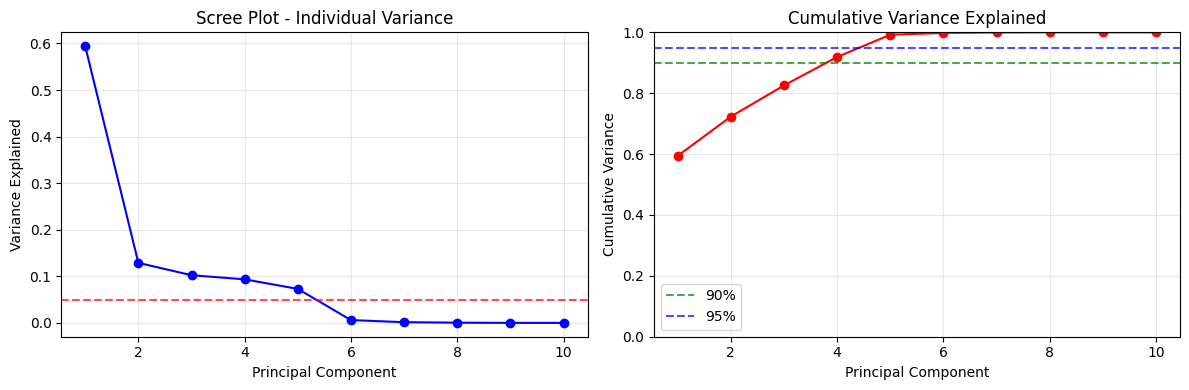

In [40]:
# Plot 1: plot (variance explained)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(variance_explained) + 1), variance_explained, 'bo-')
plt.axhline(y=0.05, color='r', linestyle='--', alpha=0.7)
plt.title('Scree Plot - Individual Variance')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'ro-')
plt.axhline(y=0.90, color='g', linestyle='--', alpha=0.7, label='90%')
plt.axhline(y=0.95, color='b', linestyle='--', alpha=0.7, label='95%')
plt.title('Cumulative Variance Explained')
plt.xlabel('Principal Component')
plt.ylabel('Cumulative Variance')
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

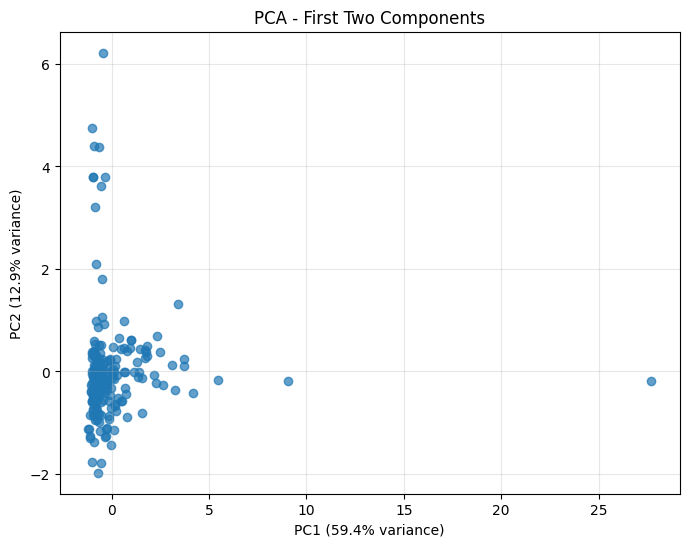

In [41]:
# Plot 2: PCA scatter plot (first two components)
if n_components_final >= 2:
    plt.figure(figsize=(8, 6))
    plt.scatter(df_pca_result['PC1'], df_pca_result['PC2'], alpha=0.7)
    plt.xlabel(f'PC1 ({pca_final.explained_variance_ratio_[0]*100:.1f}% variance)')
    plt.ylabel(f'PC2 ({pca_final.explained_variance_ratio_[1]*100:.1f}% variance)')
    plt.title('PCA - First Two Components')
    plt.grid(alpha=0.3)
    plt.show()

In [42]:
# Summary
print("\n" + "="*60)
print("PCA SUMMARY")
print("="*60)
print(f"Original features: {df_pca.shape[1]}")
print(f"PCA components: {n_components_final}")
print(f"Variance explained: {cumulative_variance[n_components_final-1]*100:.2f}%")
print(f"Dimensionality reduction: {((df_pca.shape[1] - n_components_final) / df_pca.shape[1] * 100):.1f}%")
print("\nPCA analysis completed! Yaaaay! :) - Next Step...")


PCA SUMMARY
Original features: 10
PCA components: 5
Variance explained: 99.20%
Dimensionality reduction: 50.0%

PCA analysis completed! Yaaaay! :) - Next Step...


I've reduced 10 variables to 5 (Dimensionality reduction also shows - 50%!)while keeping 99% of the information - a great trade-off for further analysis!

In [43]:
# Apply PCA (using 95% variance threshold earlier above)
pca = PCA(n_components=0.95)  # Keep 95% of variance
data_pca = pca.fit_transform(data_scaled)

In [44]:
# Show variance explained by each component
print("Variance explained by each Principal Component:")
for i, var_exp in enumerate(pca_full.explained_variance_ratio_):
    print(f"PC{i+1}: {var_exp:.4f} ({var_exp*100:.2f}%)")

Variance explained by each Principal Component:
PC1: 0.5942 (59.42%)
PC2: 0.1289 (12.89%)
PC3: 0.1024 (10.24%)
PC4: 0.0935 (9.35%)
PC5: 0.0730 (7.30%)
PC6: 0.0060 (0.60%)
PC7: 0.0015 (0.15%)
PC8: 0.0005 (0.05%)
PC9: 0.0000 (0.00%)
PC10: 0.0000 (0.00%)


In [45]:
# Cumulative variance
cumsum_var = np.cumsum(pca_full.explained_variance_ratio_)
print(f"\nCumulative variance explained:")
for i, cum_var in enumerate(cumsum_var):
    print(f"PC1 to PC{i+1}: {cum_var:.4f} ({cum_var*100:.2f}%)")


Cumulative variance explained:
PC1 to PC1: 0.5942 (59.42%)
PC1 to PC2: 0.7232 (72.32%)
PC1 to PC3: 0.8255 (82.55%)
PC1 to PC4: 0.9190 (91.90%)
PC1 to PC5: 0.9920 (99.20%)
PC1 to PC6: 0.9980 (99.80%)
PC1 to PC7: 0.9995 (99.95%)
PC1 to PC8: 1.0000 (100.00%)
PC1 to PC9: 1.0000 (100.00%)
PC1 to PC10: 1.0000 (100.00%)


In [46]:
print("Data prepared for clustering:")
print(f"Original shape: {df_pca.shape}")
print(f"PCA transformed shape: {data_pca.shape}")
print(f"Variance explained: {sum(pca.explained_variance_ratio_)*100:.1f}%")

Data prepared for clustering:
Original shape: (207, 10)
PCA transformed shape: (207, 5)
Variance explained: 99.2%


Preparing for clustering now and so we need to identify the optimal cluster with the elbow method. - that gives us an idea of the number of clusters to start with. 

3. Apply the Elbow method to select an optimum number of clusters

We will do this in steps or some sort of a pipeline. 

In [47]:
# Step 1: Apply Elbow Method
print("\n" + "="*50)
print("STEP 1: ELBOW METHOD ANALYSIS")
print("="*50)


STEP 1: ELBOW METHOD ANALYSIS


In [48]:
# Test different numbers of clusters
from sklearn.cluster import KMeans
k_range = range(1, 11)  # Test 1 to 10 clusters
wcss = []  # Within-Cluster Sum of Squares
print("Testing different numbers of clusters...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data_pca)
    wcss.append(kmeans.inertia_)  # inertia_ is the WCSS
    print(f"k={k}: WCSS = {kmeans.inertia_:.2f}")

Testing different numbers of clusters...
k=1: WCSS = 1848.16
k=2: WCSS = 1060.39
k=3: WCSS = 803.00
k=4: WCSS = 590.23
k=5: WCSS = 427.73
k=6: WCSS = 357.65
k=7: WCSS = 297.91
k=8: WCSS = 255.78
k=9: WCSS = 209.10
k=10: WCSS = 181.43


In [49]:
# Step 2: Plot the Elbow Curve
print("\n" + "="*50)
print("STEP 2: PLOTTING ELBOW CURVE")
print("="*50)


STEP 2: PLOTTING ELBOW CURVE


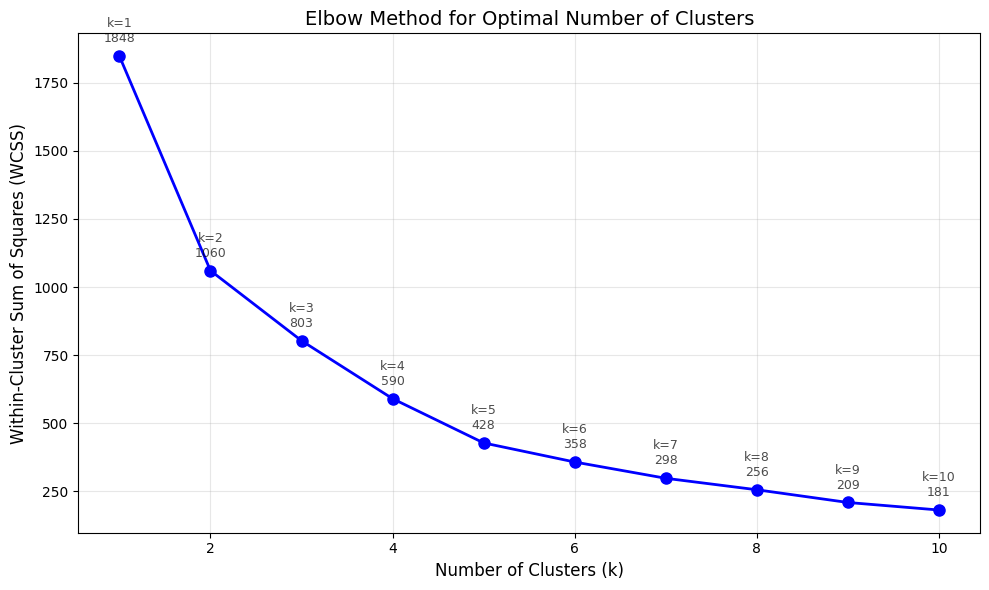

In [50]:
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, 'bo-', linewidth=2, markersize=8)
plt.title('Elbow Method for Optimal Number of Clusters', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
plt.grid(alpha=0.3)

# Add annotations for each point
for i, (k, w) in enumerate(zip(k_range, wcss)):
    plt.annotate(f'k={k}\n{w:.0f}', (k, w), textcoords="offset points", 
                xytext=(0,10), ha='center', fontsize=9, alpha=0.7)

plt.tight_layout()
plt.show()

Hmmm which is the elbow? this looks smooth!

In [51]:
# Step 3: Calculate rate of change (to help identify elbow)
print("\n" + "="*50)
print("STEP 3: ELBOW ANALYSIS")
print("="*50)


STEP 3: ELBOW ANALYSIS


In [52]:
# Calculate the differences between consecutive WCSS values
wcss_diff = [wcss[i] - wcss[i+1] for i in range(len(wcss)-1)]
print("WCSS reduction when adding one more cluster:")
for i, diff in enumerate(wcss_diff):
    print(f"k={i+1} to k={i+2}: {diff:.2f} reduction")

WCSS reduction when adding one more cluster:
k=1 to k=2: 787.77 reduction
k=2 to k=3: 257.38 reduction
k=3 to k=4: 212.78 reduction
k=4 to k=5: 162.49 reduction
k=5 to k=6: 70.08 reduction
k=6 to k=7: 59.74 reduction
k=7 to k=8: 42.13 reduction
k=8 to k=9: 46.68 reduction
k=9 to k=10: 27.67 reduction


In [53]:
# Calculate rate of change in reduction
wcss_diff2 = [wcss_diff[i] - wcss_diff[i+1] for i in range(len(wcss_diff)-1)]
print(f"\nRate of change in WCSS reduction:")
for i, diff2 in enumerate(wcss_diff2):
    print(f"k={i+2} to k={i+3}: {diff2:.2f}")


Rate of change in WCSS reduction:
k=2 to k=3: 530.39
k=3 to k=4: 44.60
k=4 to k=5: 50.29
k=5 to k=6: 92.41
k=6 to k=7: 10.34
k=7 to k=8: 17.61
k=8 to k=9: -4.55
k=9 to k=10: 19.01


In [54]:
# Step 4: optimal k based on elbow
print("\n" + "="*50)
print("STEP 4: ELBOW IDENTIFICATION")
print("="*50)


STEP 4: ELBOW IDENTIFICATION


In [55]:
# Elbow detection: find where the rate of reduction slows down significantly? Where its not changing much..
max_reduction_change = max(wcss_diff2)
optimal_k_index = wcss_diff2.index(max_reduction_change)
optimal_k = optimal_k_index + 3  # +3 because we start from k=2 to k=3 comparison
print(f"optimal k: {optimal_k}")
print(f"Reasoning behind this : Largest change in reduction rate occurs at k={optimal_k}")

optimal k: 3
Reasoning behind this : Largest change in reduction rate occurs at k=3


In [56]:
# Step 5: Apply clustering with optimal k = 3
print("\n" + "="*50)
print("STEP 5: CLUSTERING WITH OPTIMAL K")
print("="*50)


STEP 5: CLUSTERING WITH OPTIMAL K


In [81]:
# Use the optimal k = 3
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(data_pca)

print(f"Clustering completed with k={optimal_k}")
print(f"Final WCSS: {final_kmeans.inertia_:.2f}")

Clustering completed with k=3
Final WCSS: 803.00


In [82]:
# Add cluster labels to original data
df_clustered = df.copy()
df_clustered['Cluster'] = cluster_labels

In [83]:
# Show cluster sizes
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
print(f"\nCluster sizes:")
for cluster, count in cluster_counts.items():
    print(f"Cluster {cluster}: {count} municipalities ({count/len(df_clustered)*100:.1f}%)")


Cluster sizes:
Cluster 0: 177 municipalities (85.5%)
Cluster 1: 1 municipalities (0.5%)
Cluster 2: 29 municipalities (14.0%)


In [79]:
# Step 6: Visualize the clusters
print("\n" + "="*50)
print("STEP 6: CLUSTER VISUALIZATION")
print("="*50)


STEP 6: CLUSTER VISUALIZATION


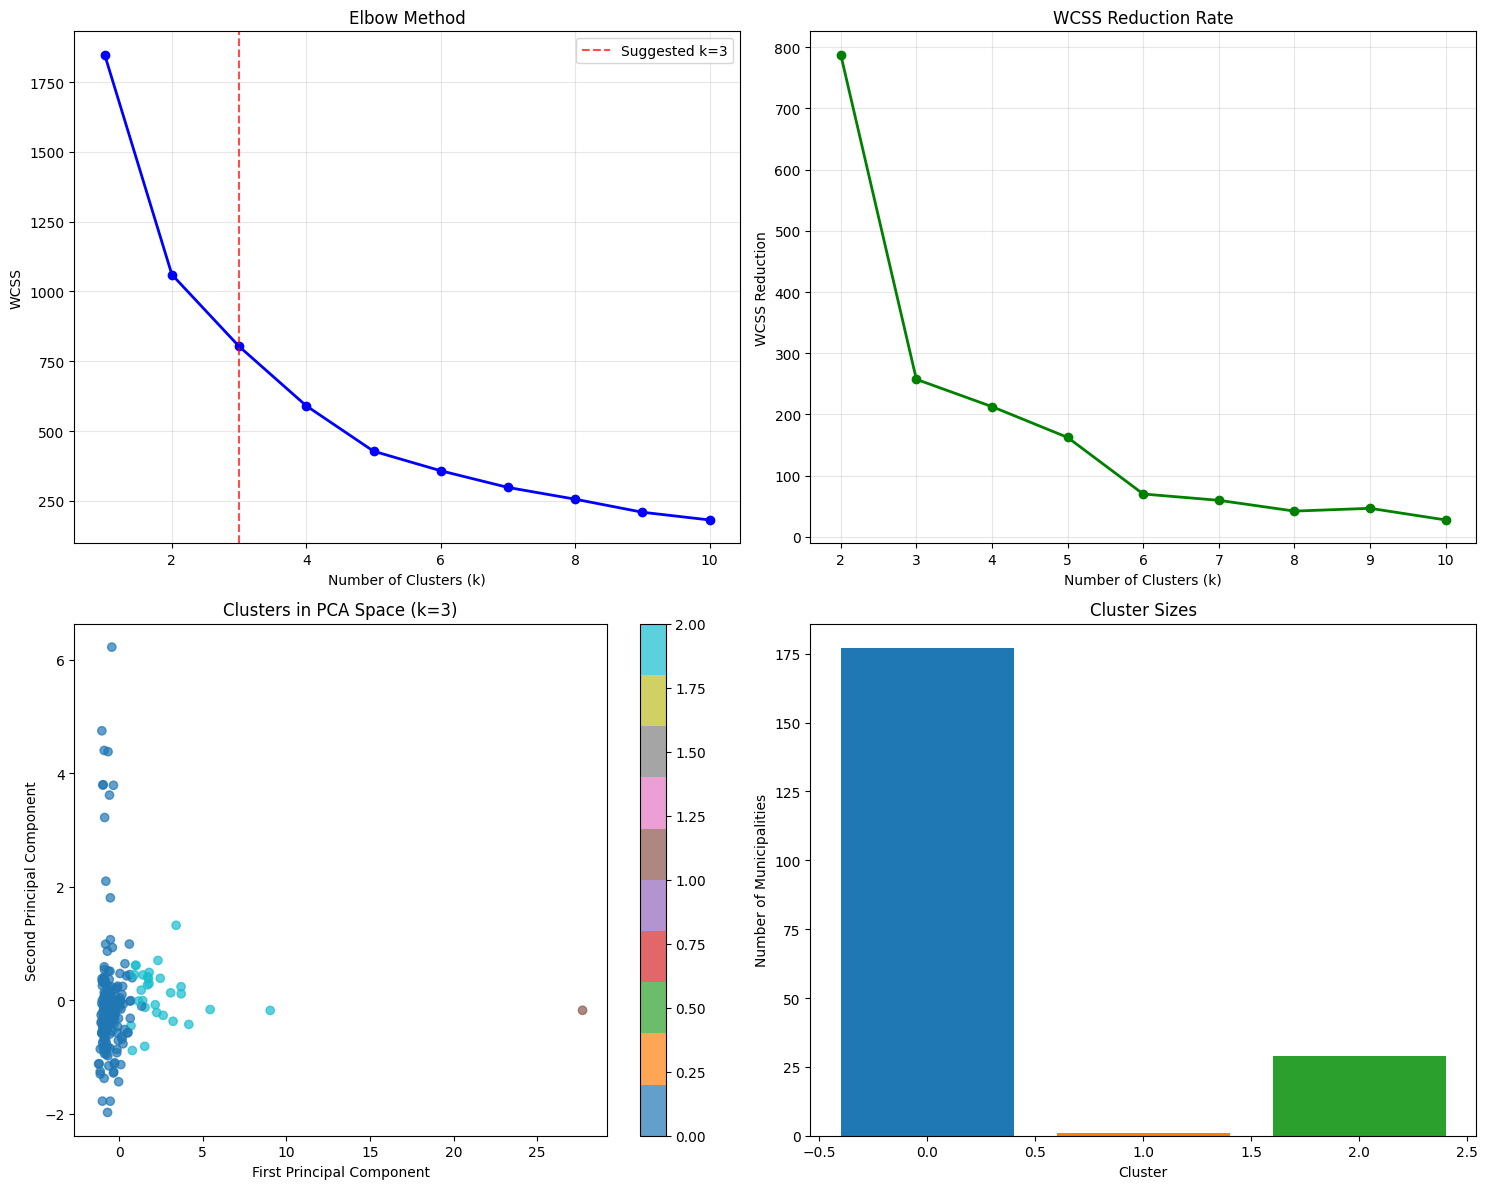

In [80]:
# Create visualization with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Elbow curve with optimal k marked
axes[0, 0].plot(k_range, wcss, 'bo-', linewidth=2)
axes[0, 0].axvline(x=optimal_k, color='red', linestyle='--', alpha=0.7, 
                   label=f'Suggested k={optimal_k}')
axes[0, 0].set_title('Elbow Method')
axes[0, 0].set_xlabel('Number of Clusters (k)')
axes[0, 0].set_ylabel('WCSS')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: WCSS reduction rate
axes[0, 1].plot(range(2, len(wcss_diff)+2), wcss_diff, 'go-', linewidth=2)
axes[0, 1].set_title('WCSS Reduction Rate')
axes[0, 1].set_xlabel('Number of Clusters (k)')
axes[0, 1].set_ylabel('WCSS Reduction')
axes[0, 1].grid(alpha=0.3)

# Plot 3: Clusters in PCA space (first 2 components)
if data_pca.shape[1] >= 2:
    scatter = axes[1, 0].scatter(data_pca[:, 0], data_pca[:, 1], 
                                c=cluster_labels, cmap='tab10', alpha=0.7)
    axes[1, 0].set_title(f'Clusters in PCA Space (k={optimal_k})')
    axes[1, 0].set_xlabel('First Principal Component')
    axes[1, 0].set_ylabel('Second Principal Component')
    plt.colorbar(scatter, ax=axes[1, 0])

# Plot 4: Cluster sizes
axes[1, 1].bar(cluster_counts.index, cluster_counts.values, 
               color=plt.cm.tab10(np.arange(len(cluster_counts))))
axes[1, 1].set_title('Cluster Sizes')
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('Number of Municipalities')

plt.tight_layout()
plt.show()

To understand the characteristics of the clusters

In [62]:
# Step 7: Analyze cluster characteristics
print("\n" + "="*50)
print("STEP 7: CLUSTER CHARACTERISTICS")
print("="*50)


STEP 7: CLUSTER CHARACTERISTICS


In [90]:
# Calculate mean values for each cluster using original meaningful variables
original_vars = ['Population', 'Revenue', 'Percent_University', 'Population_University', 'Employee', 'SalesIndex', 'Productivity', 'Infrast']  # Add other original columns you want to analyze
cluster_means = df_clustered.groupby('Cluster')[original_vars].mean()
print("Average characteristics of each cluster:")
print(cluster_means.round(2))

Average characteristics of each cluster:
         Population   Revenue  Percent_University  Population_University  \
Cluster                                                                    
0          19891.51    383.85                0.09                1898.36   
1         847073.00  32897.00                0.23              191585.00   
2          95952.14   3887.76                0.16               15070.62   

         Employee  SalesIndex  Productivity  Infrast  
Cluster                                               
0          211.12       39.55         88.46     0.04  
1        18795.00     3389.67         87.72     1.00  
2         1796.76      400.59        109.83     0.07  


In [91]:
# Show some example municipalities from each cluster
print(f"\nExample municipalities from each cluster:")
municipality_names = df['Kommun_name'].loc[df_clustered.index]
for cluster in range(optimal_k):
    cluster_munis = municipality_names[df_clustered['Cluster'] == cluster]
    sample_munis = cluster_munis.head(3).tolist()
    print(f"Cluster {cluster}: {', '.join(sample_munis)} (and {len(cluster_munis)-3} others)")



Example municipalities from each cluster:
Cluster 0: Haparanda, Upplands Väsby, Vallentuna (and 174 others)
Cluster 1: Stockholm (and -2 others)
Cluster 2: Kalmar, Karlstad, Järfälla (and 26 others)


In [93]:
# Summary
print("\n" + "="*60)
print("CLUSTERING SUMMARY")
print("="*60)
print(f"Optimal number of clusters: {optimal_k}")
print(f"Total municipalities: {len(df_clustered)}")
print(f"WCSS with optimal k: {final_kmeans.inertia_:.2f}")
print(f"Data used: PCA-transformed ({data_pca.shape[1]} components)")


CLUSTERING SUMMARY
Optimal number of clusters: 3
Total municipalities: 207
WCSS with optimal k: 803.00
Data used: PCA-transformed (5 components)


5. Append cluster labels column to the original df.

In [66]:
# After clustering is done, add labels to original df
df_clustered = df.copy()
df_clustered['Cluster'] = cluster_labels

# Now lets view it:
print(df_clustered[['Kommun_name', 'Cluster']].head(10))

      Kommun_name  Cluster
0       Haparanda        0
1          Kalmar        2
2        Karlstad        2
3  Upplands Väsby        0
4      Vallentuna        0
5       Österåker        0
6          Värmdö        0
7        Järfälla        2
8           Ekerö        0
9        Huddinge        2


List of Municipalities with Ikea provided in Instructions

In [95]:
# List of municipalities with existing IKEA stores
existing_ikea_stores = [
    'Borlänge', 'Gävle', 'Göteborg', 'Haparanda', 'Helsingborg', 
    'Jönköping', 'Kalmar', 'Karlstad', 'Linköping', 'Malmö', 
    'Stockholm', 'Sundsvall', 'Uddevalla', 'Umeå', 'Uppsala', 
    'Västerås', 'Älmhult', 'Örebro'
]
print(f"\nExisting IKEA stores: {len(existing_ikea_stores)}")
print(f"Stores: {existing_ikea_stores}")


Existing IKEA stores: 18
Stores: ['Borlänge', 'Gävle', 'Göteborg', 'Haparanda', 'Helsingborg', 'Jönköping', 'Kalmar', 'Karlstad', 'Linköping', 'Malmö', 'Stockholm', 'Sundsvall', 'Uddevalla', 'Umeå', 'Uppsala', 'Västerås', 'Älmhult', 'Örebro']


In [68]:
# Add the has_ikea column
df['has_ikea'] = df['Kommun_name'].isin(existing_ikea_stores).astype(int)
print(f"\nAfter adding has_ikea column:")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")


After adding has_ikea column:
Shape: (207, 13)
Columns: ['Kommun_code', 'Year', 'Kommun_name', 'Revenue', 'Employee', 'Population', 'Population_University', 'Percent_University', 'Productivity', 'SalesIndex', 'Infrast', 'Border', 'has_ikea']


In [69]:
# Verify the results
print(f"\nVerification:")
print(f"Total municipalities in dataset: {len(df)}")
print(f"Municipalities with IKEA stores: {df['has_ikea'].sum()}")
print(f"Municipalities without IKEA stores: {(df['has_ikea'] == 0).sum()}")


Verification:
Total municipalities in dataset: 207
Municipalities with IKEA stores: 12
Municipalities without IKEA stores: 195


In [70]:
# Show which IKEA stores are found in the dataset
ikea_in_data = df[df['has_ikea'] == 1]['Kommun_name'].tolist()
ikea_missing = [store for store in existing_ikea_stores if store not in ikea_in_data]

print(f"\nIKEA stores found in dataset: {len(ikea_in_data)}")
print(f"Found: {ikea_in_data}")

print(f"\nIKEA stores missing from dataset: {len(ikea_missing)}")
print(f"Missing: {ikea_missing}")


IKEA stores found in dataset: 12
Found: ['Haparanda', 'Kalmar', 'Karlstad', 'Stockholm', 'Uppsala', 'Linköping', 'Jönköping', 'Älmhult', 'Malmö', 'Helsingborg', 'Uddevalla', 'Örebro']

IKEA stores missing from dataset: 6
Missing: ['Borlänge', 'Gävle', 'Göteborg', 'Sundsvall', 'Umeå', 'Västerås']


In [71]:
# Show sample of municipalities with IKEA stores
print(f"\nSample municipalities with IKEA stores:")
print(df[df['has_ikea'] == 1][['Kommun_name', 'Population', 'Revenue', 'has_ikea']].head())

# Show sample of municipalities without IKEA stores
print(f"\nSample municipalities without IKEA stores:")
print(df[df['has_ikea'] == 0][['Kommun_name', 'Population', 'Revenue', 'has_ikea']].head())


Sample municipalities with IKEA stores:
   Kommun_name  Population  Revenue  has_ikea
0    Haparanda       10059     1078         1
1       Kalmar       62815     3790         1
2     Karlstad       85753     4560         1
19   Stockholm      847073    32897         1
33     Uppsala      197787     7042         1

Sample municipalities without IKEA stores:
      Kommun_name  Population  Revenue  has_ikea
3  Upplands Väsby       39289     1366         0
4      Vallentuna       30114      171         0
5       Österåker       39521      563         0
6          Värmdö       38301      920         0
7        Järfälla       66211     5119         0


In [72]:
# Basic statistics comparison
print(f"\nComparison between municipalities with and without IKEA:")
print("Municipalities WITH IKEA stores:")
ikea_stats = df[df['has_ikea'] == 1][['Population', 'Revenue', 'Percent_University']].mean()
print(f"  Average Population: {ikea_stats['Population']:,.0f}")
print(f"  Average Revenue: {ikea_stats['Revenue']:,.0f}")
print(f"  Average University %: {ikea_stats['Percent_University']:.3f}")

print("\nMunicipalities WITHOUT IKEA stores:")
no_ikea_stats = df[df['has_ikea'] == 0][['Population', 'Revenue', 'Percent_University']].mean()
print(f"  Average Population: {no_ikea_stats['Population']:,.0f}")
print(f"  Average Revenue: {no_ikea_stats['Revenue']:,.0f}")
print(f"  Average University %: {no_ikea_stats['Percent_University']:.3f}")

print(f"\nDataset with has_ikea column is ready for analysis!")
print(f"Final shape: {df.shape}")


Comparison between municipalities with and without IKEA:
Municipalities WITH IKEA stores:
  Average Population: 175,696
  Average Revenue: 7,178
  Average University %: 0.146

Municipalities WITHOUT IKEA stores:
  Average Population: 25,857
  Average Revenue: 654
  Average University %: 0.094

Dataset with has_ikea column is ready for analysis!
Final shape: (207, 13)


7. Explore the clusters - you will probably find them separated into small,medium, and large municipalities

In [73]:
print("="*60)
print("CLUSTER EXPLORATION ANALYSIS")
print("="*60)
print(f"Total municipalities: {len(df_clustered)}")
print(f"Number of clusters: {optimal_k}")

CLUSTER EXPLORATION ANALYSIS
Total municipalities: 207
Number of clusters: 3


Doing this Step by Step

In [95]:
# Step 1: Analyze each cluster's basic characteristics
print("\n" + "="*50)
print("STEP 1: CLUSTER SIZE AND BASIC CHARACTERISTICS")
print("="*50)


STEP 1: CLUSTER SIZE AND BASIC CHARACTERISTICS


In [98]:
# Recreate df_clustered with the updated df that has has_ikea
df_clustered = df.copy()
df_clustered['Cluster'] = cluster_labels

In [99]:
cluster_summary = []
for cluster in range(optimal_k):
    cluster_data = df_clustered[df_clustered['Cluster'] == cluster]
    
    summary = {
        'Cluster': cluster,
        'Count': len(cluster_data),
        'Percentage': len(cluster_data) / len(df_clustered) * 100,
        'Avg_Population': cluster_data['Population'].mean(),
        'Min_Population': cluster_data['Population'].min(),
        'Max_Population': cluster_data['Population'].max(),
        'Avg_Revenue': cluster_data['Revenue'].mean(),
        'Avg_University_Pct': cluster_data['Percent_University'].mean(),
        'IKEA_Count': cluster_data['has_ikea'].sum(),
        'IKEA_Penetration': cluster_data['has_ikea'].mean() * 100
    }
    cluster_summary.append(summary)

In [101]:
# Convert to dataframe for easy viewing
cluster_df = pd.DataFrame(cluster_summary)
print("Cluster Summary:")
print(cluster_df.round(2))

Cluster Summary:
   Cluster  Count  Percentage  Avg_Population  Min_Population  Max_Population  \
0        0    177       85.51        19891.51            3672           82608   
1        1      1        0.48       847073.00          847073          847073   
2        2     29       14.01        95952.14           31330          298963   

   Avg_Revenue  Avg_University_Pct  IKEA_Count  IKEA_Penetration  
0       383.85                0.09           3              1.69  
1     32897.00                0.23           1            100.00  
2      3887.76                0.16           8             27.59  


The above analysis is to provide variable information about the clusters. Average Population and Revenue is highest in Cluster 1 and lowest in Cluster 0. Count is 1 for highest and 3 for lowest. 

In [98]:
# Step 2: Classify clusters by size
print("\n" + "="*50)
print("STEP 2: MUNICIPALITY SIZE CLASSIFICATION")
print("="*50)


STEP 2: MUNICIPALITY SIZE CLASSIFICATION


In [102]:
# Sort clusters by average population to identify small/medium/large
cluster_df_sorted = cluster_df.sort_values('Avg_Population')

# Classify based on population ranges
def classify_size(avg_pop):
    if avg_pop < 20000:
        return "Small"
    elif avg_pop < 80000:
        return "Medium"
    else:
        return "Large"

cluster_df_sorted['Size_Category'] = cluster_df_sorted['Avg_Population'].apply(classify_size)

print("Clusters by Size Category:")
for _, row in cluster_df_sorted.iterrows():
    print(f"\nCluster {int(row['Cluster'])} - {row['Size_Category']} Municipalities:")
    print(f"  Count: {int(row['Count'])} municipalities ({row['Percentage']:.1f}%)")
    print(f"  Population range: {int(row['Min_Population']):,} - {int(row['Max_Population']):,}")
    print(f"  Average population: {int(row['Avg_Population']):,}")
    print(f"  Average revenue: {int(row['Avg_Revenue']):,}")
    print(f"  Average university %: {row['Avg_University_Pct']:.1%}")
    print(f"  IKEA stores: {int(row['IKEA_Count'])} ({row['IKEA_Penetration']:.1f}% penetration)")

Clusters by Size Category:

Cluster 0 - Small Municipalities:
  Count: 177 municipalities (85.5%)
  Population range: 3,672 - 82,608
  Average population: 19,891
  Average revenue: 383
  Average university %: 8.7%
  IKEA stores: 3 (1.7% penetration)

Cluster 2 - Large Municipalities:
  Count: 29 municipalities (14.0%)
  Population range: 31,330 - 298,963
  Average population: 95,952
  Average revenue: 3,887
  Average university %: 15.8%
  IKEA stores: 8 (27.6% penetration)

Cluster 1 - Large Municipalities:
  Count: 1 municipalities (0.5%)
  Population range: 847,073 - 847,073
  Average population: 847,073
  Average revenue: 32,897
  Average university %: 22.6%
  IKEA stores: 1 (100.0% penetration)


In this dataset, Cluster 0 has 85% of the municipalities(small) and yet with the lowest penetration rate of ikea stores. Cluster 1 has 100% penetration with 1 ikea store in 1 municipality. We could explore the characteristics of Cluster 2.Population Range and Average University looks like something ti look into. 

In [104]:
# Step 3: example municipalities from each cluster
print("\n" + "="*50)
print("STEP 3: EXAMPLE MUNICIPALITIES BY CLUSTER")
print("="*50)

for cluster in range(optimal_k):
    cluster_data = df_clustered[df_clustered['Cluster'] == cluster]
    cluster_info = cluster_df[cluster_df['Cluster'] == cluster].iloc[0]
    
    print(f"\nCluster {cluster} - {classify_size(cluster_info['Avg_Population'])} Municipalities:")


STEP 3: EXAMPLE MUNICIPALITIES BY CLUSTER

Cluster 0 - Small Municipalities:

Cluster 1 - Large Municipalities:

Cluster 2 - Large Municipalities:


In [105]:
# Show municipalities with IKEA stores first
ikea_munis = cluster_data[cluster_data['has_ikea'] == 1]
if len(ikea_munis) > 0:
        print("  WITH IKEA stores:")
        for _, row in ikea_munis.iterrows():
            print(f"    {row['Kommun_name']} (Pop: {row['Population']:,}, Rev: {row['Revenue']:,})")
    
    # Show some municipalities without IKEA stores
no_ikea_munis = cluster_data[cluster_data['has_ikea'] == 0].sort_values('Population', ascending=False)
print("\nWITHOUT IKEA stores (largest by population):")
for _, row in no_ikea_munis.head(5).iterrows():
        print(f"    {row['Kommun_name']} (Pop: {row['Population']:,}, Rev: {row['Revenue']:,})")

  WITH IKEA stores:
    Kalmar (Pop: 62,815, Rev: 3,790)
    Karlstad (Pop: 85,753, Rev: 4,560)
    Uppsala (Pop: 197,787, Rev: 7,042)
    Linköping (Pop: 146,416, Rev: 5,348)
    Jönköping (Pop: 127,382, Rev: 5,298)
    Malmö (Pop: 298,963, Rev: 11,217)
    Helsingborg (Pop: 129,177, Rev: 5,528)
    Örebro (Pop: 135,460, Rev: 6,228)

WITHOUT IKEA stores (largest by population):
    Norrköping (Pop: 130,050, Rev: 4,438)
    Lund (Pop: 110,488, Rev: 3,438)
    Borås (Pop: 103,294, Rev: 3,365)
    Huddinge (Pop: 97,453, Rev: 7,153)
    Eskilstuna (Pop: 96,311, Rev: 2,844)


In [106]:
# Step 4: Visualize the clusters
print("\n" + "="*50)
print("STEP 4: CLUSTER VISUALIZATIONS")
print("="*50)


STEP 4: CLUSTER VISUALIZATIONS


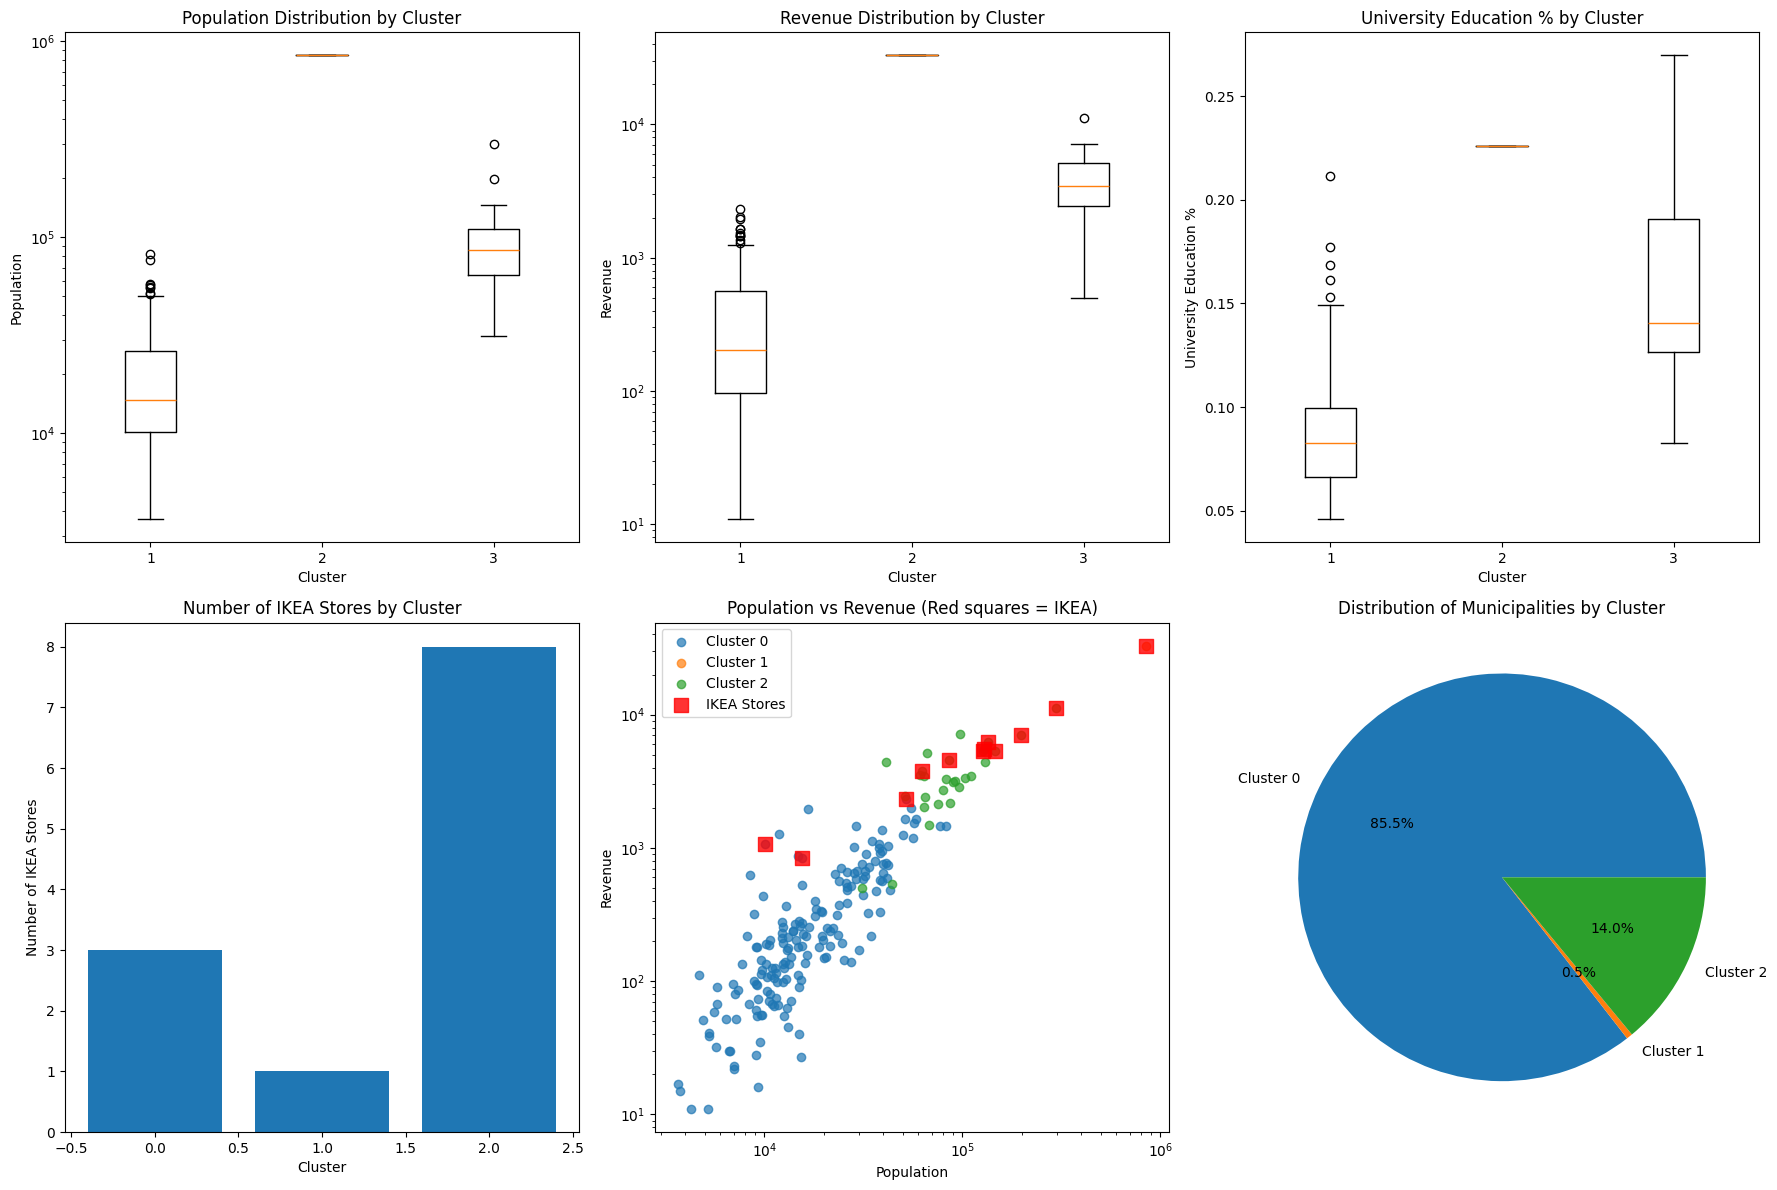

In [107]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Population distribution by cluster
axes[0, 0].boxplot([df_clustered[df_clustered['Cluster'] == i]['Population'] for i in range(optimal_k)])
axes[0, 0].set_title('Population Distribution by Cluster')
axes[0, 0].set_xlabel('Cluster')
axes[0, 0].set_ylabel('Population')
axes[0, 0].set_yscale('log')

# Plot 2: Revenue distribution by cluster
axes[0, 1].boxplot([df_clustered[df_clustered['Cluster'] == i]['Revenue'] for i in range(optimal_k)])
axes[0, 1].set_title('Revenue Distribution by Cluster')
axes[0, 1].set_xlabel('Cluster')
axes[0, 1].set_ylabel('Revenue')
axes[0, 1].set_yscale('log')

# Plot 3: University education by cluster
axes[0, 2].boxplot([df_clustered[df_clustered['Cluster'] == i]['Percent_University'] for i in range(optimal_k)])
axes[0, 2].set_title('University Education % by Cluster')
axes[0, 2].set_xlabel('Cluster')
axes[0, 2].set_ylabel('University Education %')

# Plot 4: IKEA presence by cluster
ikea_by_cluster = [df_clustered[df_clustered['Cluster'] == i]['has_ikea'].sum() for i in range(optimal_k)]
axes[1, 0].bar(range(optimal_k), ikea_by_cluster)
axes[1, 0].set_title('Number of IKEA Stores by Cluster')
axes[1, 0].set_xlabel('Cluster')
axes[1, 0].set_ylabel('Number of IKEA Stores')

# Plot 5: Population vs Revenue colored by cluster
colors = plt.cm.tab10(np.arange(optimal_k))
for cluster in range(optimal_k):
    cluster_data = df_clustered[df_clustered['Cluster'] == cluster]
    axes[1, 1].scatter(cluster_data['Population'], cluster_data['Revenue'], 
                      c=[colors[cluster]], label=f'Cluster {cluster}', alpha=0.7)
   
# Highlight IKEA stores
ikea_data = df_clustered[df_clustered['has_ikea'] == 1]
axes[1, 1].scatter(ikea_data['Population'], ikea_data['Revenue'], 
                  c='red', s=100, marker='s', label='IKEA Stores', alpha=0.8)

axes[1, 1].set_xlabel('Population')
axes[1, 1].set_ylabel('Revenue')
axes[1, 1].set_title('Population vs Revenue (Red squares = IKEA)')
axes[1, 1].legend()
axes[1, 1].set_xscale('log')
axes[1, 1].set_yscale('log')

# Plot 6: Cluster sizes
cluster_sizes = df_clustered['Cluster'].value_counts().sort_index()
axes[1, 2].pie(cluster_sizes.values, labels=[f'Cluster {i}' for i in cluster_sizes.index], 
              autopct='%1.1f%%')
axes[1, 2].set_title('Distribution of Municipalities by Cluster')

plt.tight_layout()
plt.show()

In [108]:
# Step 5: Statistical analysis
print("\n" + "="*50)
print("STEP 5: STATISTICAL INSIGHTS")
print("="*50)


STEP 5: STATISTICAL INSIGHTS


In [153]:
print("Key Findings:")
print(f"1. Cluster sizes: {dict(cluster_sizes)}")

# Find which cluster type has most IKEA stores
for category in ['Small', 'Medium', 'Large']:
    category_clusters = cluster_df_sorted[cluster_df_sorted['Size_Category'] == category]['Cluster'].tolist()
    total_ikea = sum([df_clustered[df_clustered['Cluster'] == c]['has_ikea'].sum() for c in category_clusters])
    total_munis = sum([len(df_clustered[df_clustered['Cluster'] == c]) for c in category_clusters])
    penetration = total_ikea / total_munis * 100 if total_munis > 0 else 0
    
    print(f"2. {category} municipalities: {total_munis} total, {total_ikea} IKEA stores ({penetration:.1f}% penetration)")
print("\n3. Characteristics of successful IKEA locations:")
ikea_municipalities = df_clustered[df_clustered['has_ikea'] == 1]
print(f"   Average population: {ikea_municipalities['Population'].mean():,.0f}")
print(f"   Average university education: {ikea_municipalities['Percent_University'].mean():.1%}")
print(f"   Average revenue: {ikea_municipalities['Revenue'].mean():,.0f}")

print(f"\nCluster exploration completed!")

Key Findings:
1. Cluster sizes: {0: np.int64(177), 1: np.int64(1), 2: np.int64(29)}
2. Small municipalities: 177 total, 3 IKEA stores (1.7% penetration)
2. Medium municipalities: 0 total, 0 IKEA stores (0.0% penetration)
2. Large municipalities: 30 total, 9 IKEA stores (30.0% penetration)

3. Characteristics of successful IKEA locations:
   Average population: 175,696
   Average university education: 14.6%
   Average revenue: 7,178

Cluster exploration completed!


Based on these key findings of characteristics we can create a score for further analysis. The score will look at Population, University Education etc all the variables that explain 90-95% of variance. 

With these characteristics in mind I can explore location potential!

8. Analyse them based on, for example, population, sales index, revenue etc., exclude where IKEA already exists or is close to existing IKEA

In [110]:
print("IKEA EXPANSION LOCATION ANALYSIS")
print("="*60)
print(f"Total municipalities: {len(df_clustered)}")
print(f"Existing IKEA stores: {df_clustered['has_ikea'].sum()}")
print(f"Potential locations: {(df_clustered['has_ikea'] == 0).sum()}")

IKEA EXPANSION LOCATION ANALYSIS
Total municipalities: 207
Existing IKEA stores: 12
Potential locations: 195


Step by Step to find Ikea Location for potential

In [111]:
# Step 1: Identify target clusters (clusters with successful IKEA stores)
print("\n" + "="*50)
print("STEP 1: IDENTIFY TARGET CLUSTERS")
print("="*50)


STEP 1: IDENTIFY TARGET CLUSTERS


In [113]:
cluster_ikea_analysis = []
for cluster in range(optimal_k):
    cluster_data = df_clustered[df_clustered['Cluster'] == cluster]
    ikea_count = cluster_data['has_ikea'].sum()
    total_count = len(cluster_data)
    
    analysis = {
        'Cluster': cluster,
        'Total_Municipalities': total_count,
        'IKEA_Stores': ikea_count,
        'IKEA_Penetration': ikea_count / total_count * 100,
        'Avg_Population': cluster_data['Population'].mean(),
        'Avg_Revenue': cluster_data['Revenue'].mean(),
        'Avg_SalesIndex': cluster_data['SalesIndex'].mean(),
        'Avg_University_Pct': cluster_data['Percent_University'].mean(),
        'Avg_Productivity': cluster_data['Productivity'].mean()
    }
    cluster_ikea_analysis.append(analysis)
cluster_analysis_df = pd.DataFrame(cluster_ikea_analysis)
print("Cluster Analysis:")
print(cluster_analysis_df.round(2))

Cluster Analysis:
   Cluster  Total_Municipalities  IKEA_Stores  IKEA_Penetration  \
0        0                   177            3              1.69   
1        1                     1            1            100.00   
2        2                    29            8             27.59   

   Avg_Population  Avg_Revenue  Avg_SalesIndex  Avg_University_Pct  \
0        19891.51       383.85           39.55                0.09   
1       847073.00     32897.00         3389.67                0.23   
2        95952.14      3887.76          400.59                0.16   

   Avg_Productivity  
0             88.46  
1             87.72  
2            109.83  


In [114]:
# Identify target clusters (clusters with IKEA stores)
target_clusters = cluster_analysis_df[cluster_analysis_df['IKEA_Stores'] > 0]['Cluster'].tolist()
print(f"\nTarget clusters (with IKEA stores): {target_clusters}")


Target clusters (with IKEA stores): [0, 1, 2]


In [115]:
# Step 2: Analyze municipalities without IKEA in target clusters
print("\n" + "="*50)
print("STEP 2: EXPANSION CANDIDATES IN TARGET CLUSTERS")
print("="*50)


STEP 2: EXPANSION CANDIDATES IN TARGET CLUSTERS


In [116]:
# Filter candidates: no IKEA + in successful clusters
expansion_candidates = df_clustered[
    (df_clustered['has_ikea'] == 0) & 
    (df_clustered['Cluster'].isin(target_clusters))
].copy()

print(f"Municipalities in target clusters without IKEA: {len(expansion_candidates)}")

Municipalities in target clusters without IKEA: 195


9. Suggest top 3 candidates for opening new IKEA stores

In [117]:
if len(expansion_candidates) > 0:   
# Step 3: Score and rank candidates
    print("\n" + "="*50)
    print("STEP 3: SCORING AND RANKING CANDIDATES")
    print("="*50)


STEP 3: SCORING AND RANKING CANDIDATES


Scoring was done based on Cluster 2 characteristics: 

Avg_Population  Avg_Revenue     Avg_SalesIndex      Avg_University_Pct
95952.14      	3887.76          400.59             0.16  

Score benchmark and weight used - Potential should have these characteristics:
Population      Revenue         SalesIndex         University_Pct
100,000      	5000             500                0.25

Each was assigned a weight for points as well 

POPULATION SCORE (30 points max):
Rationale:
   IKEA needs minimum market size (~50,000+ people)
   Larger population = more potential customers
   100,000 population = optimal threshold for full points
   Highest weight because market size is IMPORTANT!
   
UNIVERSITY EDUCATION SCORE (25 points max):
Rationale:
   IKEA's core customers: educated, middle-class families
   University education correlates with:
     Higher disposable income
     DIY furniture acceptance (Isnt that what IKEA is known for?)
   Swedish average ~20% = ~20 points

SALES INDEX SCORE (20 points max):
Rationale:
   Relative sales performance indicator
   Higher index = more active consumer market
   500 threshold based on successful IKEA locations
   Indicates purchasing power and retail infrastructure

REVENUE POTENTIAL SCORE (15 points max):
Rationale:
   Indicates economic activity and business environment
   Higher revenue suggests:
      More disposable income in area
      Active local economy
      Business-friendly environment
      5,000 threshold from Cluster Characteristics

INFRASTRUCTURE SCORE (10 points max):
Rationale:
   IKEA needs good logistics and transportation
   Customer accessibility is crucial
   Infrastructure affects:
     Delivery costs and efficiency
     Customer convenience

Strategic Recommendations:
• Focus on municipalities with population > 50,000
• Prioritize locations with high university education rates
• Target clusters [2] show proven IKEA success

In [118]:
# Create business attractiveness score based on the identified characteristics 
def calculate_ikea_score(row):
        # Normalize factors (higher is better)
        pop_score = min(row['Population'] / 100000, 1.0) * 30  # Max 30 points for population
        uni_score = row['Percent_University'] * 100 * 25       # Max 25 points for education
        sales_score = min(row['SalesIndex'] / 500, 1.0) * 20   # Max 20 points for sales index
        revenue_score = min(row['Revenue'] / 5000, 1.0) * 15   # Max 15 points for revenue potential
        infra_score = row['Infrast'] * 10                      # Max 10 points for infrastructure
        
        total_score = pop_score + uni_score + sales_score + revenue_score + infra_score
        return total_score
    
expansion_candidates['IKEA_Score'] = expansion_candidates.apply(calculate_ikea_score, axis=1)
    

In [119]:
# Rank by score
expansion_candidates = expansion_candidates.sort_values('IKEA_Score', ascending=False)
    
print("Scoring criteria:")
print("- Population (30%): Larger market size")
print("- University Education (25%): Target demographic")
print("- Sales Index (20%): Market performance indicator")
print("- Revenue Potential (15%): Economic activity")
print("- Infrastructure (10%): Logistics and accessibility")

Scoring criteria:
- Population (30%): Larger market size
- University Education (25%): Target demographic
- Sales Index (20%): Market performance indicator
- Revenue Potential (15%): Economic activity
- Infrastructure (10%): Logistics and accessibility


In [120]:
# Step 4: Show top recommendations
print("\n" + "="*50)
print("STEP 4: TOP IKEA EXPANSION RECOMMENDATIONS")
print("="*50)
    
top_candidates = expansion_candidates.head(15)


STEP 4: TOP IKEA EXPANSION RECOMMENDATIONS


In [122]:
print("Top 15 recommended municipalities for IKEA expansion:")
print("-" * 80)

for i, (_, row) in enumerate(top_candidates.head(15).iterrows(), 1):
        print(f"{i:2d}. {row['Kommun_name']} (Cluster {row['Cluster']})")
        print(f"    Score: {row['IKEA_Score']:.1f}/100")
        print(f"    Population: {row['Population']:,}")
        print(f"    University Education: {row['Percent_University']:.1%}")
        print(f"    Sales Index: {row['SalesIndex']:.0f}")
        print(f"    Revenue: {row['Revenue']:,}")
        print(f"    Infrastructure: {row['Infrast']}")
        print(f"    Border Municipality: {'Yes' if row['Border'] else 'No'}")
        print()

Top 15 recommended municipalities for IKEA expansion:
--------------------------------------------------------------------------------
 1. Lund (Cluster 2)
    Score: 715.9/100
    Population: 110,488
    University Education: 26.5%
    Sales Index: 354
    Revenue: 3,438
    Infrastructure: 0
    Border Municipality: No

 2. Danderyd (Cluster 2)
    Score: 687.1/100
    Population: 31,330
    University Education: 27.0%
    Sales Index: 52
    Revenue: 500
    Infrastructure: 0
    Border Municipality: No

 3. Solna (Cluster 2)
    Score: 619.4/100
    Population: 68,144
    University Education: 23.5%
    Sales Index: 154
    Revenue: 1,491
    Infrastructure: 0
    Border Municipality: No

 4. Lidingö (Cluster 2)
    Score: 586.7/100
    Population: 44,017
    University Education: 22.8%
    Sales Index: 55
    Revenue: 533
    Infrastructure: 0
    Border Municipality: No

 5. Täby (Cluster 2)
    Score: 570.5/100
    Population: 63,789
    University Education: 21.1%
    Sales Ind

this is the top 15 based on the score but you also do not want the top 3 recommendations too close to where there is "an ikea" - at least not too close. 100% penetration means Stockholm area is saturated. So my top 3 will be based on geographic diversification. 

In [127]:
print("\n" + "="*50)
print("TOP 3 IKEA EXPANSION RECOMMENDATIONS")
print("="*50)


TOP 3 IKEA EXPANSION RECOMMENDATIONS


1. Lund - Student Town and alos close to Malmo and Denmark
Highest score (715.9)
Great Ikea demographic: 26.5% university education
Large population (110K)
Southern Sweden location provides new market coverage
2. Täby - Strong Stockholm market
High score (570.5)
Excellent sales index (355) and revenue (3,441)
Affluent Stockholm suburb (63K population)
3. Växjö - Regional expansion
Regional center in southern Sweden (83K population)
Geographic diversification from the already saturated Stockholm area
score (417.6)
Expands Ikea's reach 
Huddinge may have the highest population and highest sales index but i skip it because its still in the Stcockholm catchment area and has low University Education.

In [125]:
 # Step 5: Analyze by cluster
print("\n" + "="*50)
print("STEP 5: RECOMMENDATIONS BY CLUSTER TYPE")
print("="*50)


STEP 5: RECOMMENDATIONS BY CLUSTER TYPE


In [118]:
for cluster in target_clusters:
        cluster_candidates = expansion_candidates[expansion_candidates['Cluster'] == cluster]
        cluster_info = cluster_analysis_df[cluster_analysis_df['Cluster'] == cluster].iloc[0]
        
        if len(cluster_candidates) > 0:
            print(f"\nCluster {cluster} Recommendations:")
            print(f"  Cluster characteristics: Avg Pop={cluster_info['Avg_Population']:,.0f}, "
                  f"Avg Revenue={cluster_info['Avg_Revenue']:,.0f}")
            print(f"  Current IKEA penetration: {cluster_info['IKEA_Penetration']:.1f}%")
            print(f"  Top candidates:")
            
            for _, row in cluster_candidates.head(3).iterrows():
                print(f"    - {row['Kommun_name']} (Score: {row['IKEA_Score']:.1f})")


Cluster 0 Recommendations:
  Cluster characteristics: Avg Pop=19,892, Avg Revenue=384
  Current IKEA penetration: 1.7%
  Top candidates:
    - Lomma (Score: 537.0)
    - Vaxholm (Score: 447.5)
    - Sundbyberg (Score: 437.6)

Cluster 2 Recommendations:
  Cluster characteristics: Avg Pop=95,952, Avg Revenue=3,888
  Current IKEA penetration: 27.6%
  Top candidates:
    - Lund (Score: 715.9)
    - Danderyd (Score: 687.1)
    - Solna (Score: 619.4)


In [120]:
 # Step 6: Visualizations
print("\n" + "="*50)
print("STEP 6: EXPANSION ANALYSIS VISUALIZATIONS")
print("="*50)


STEP 6: EXPANSION ANALYSIS VISUALIZATIONS


Text(0.5, 1.0, 'Distribution of Candidates by Cluster')

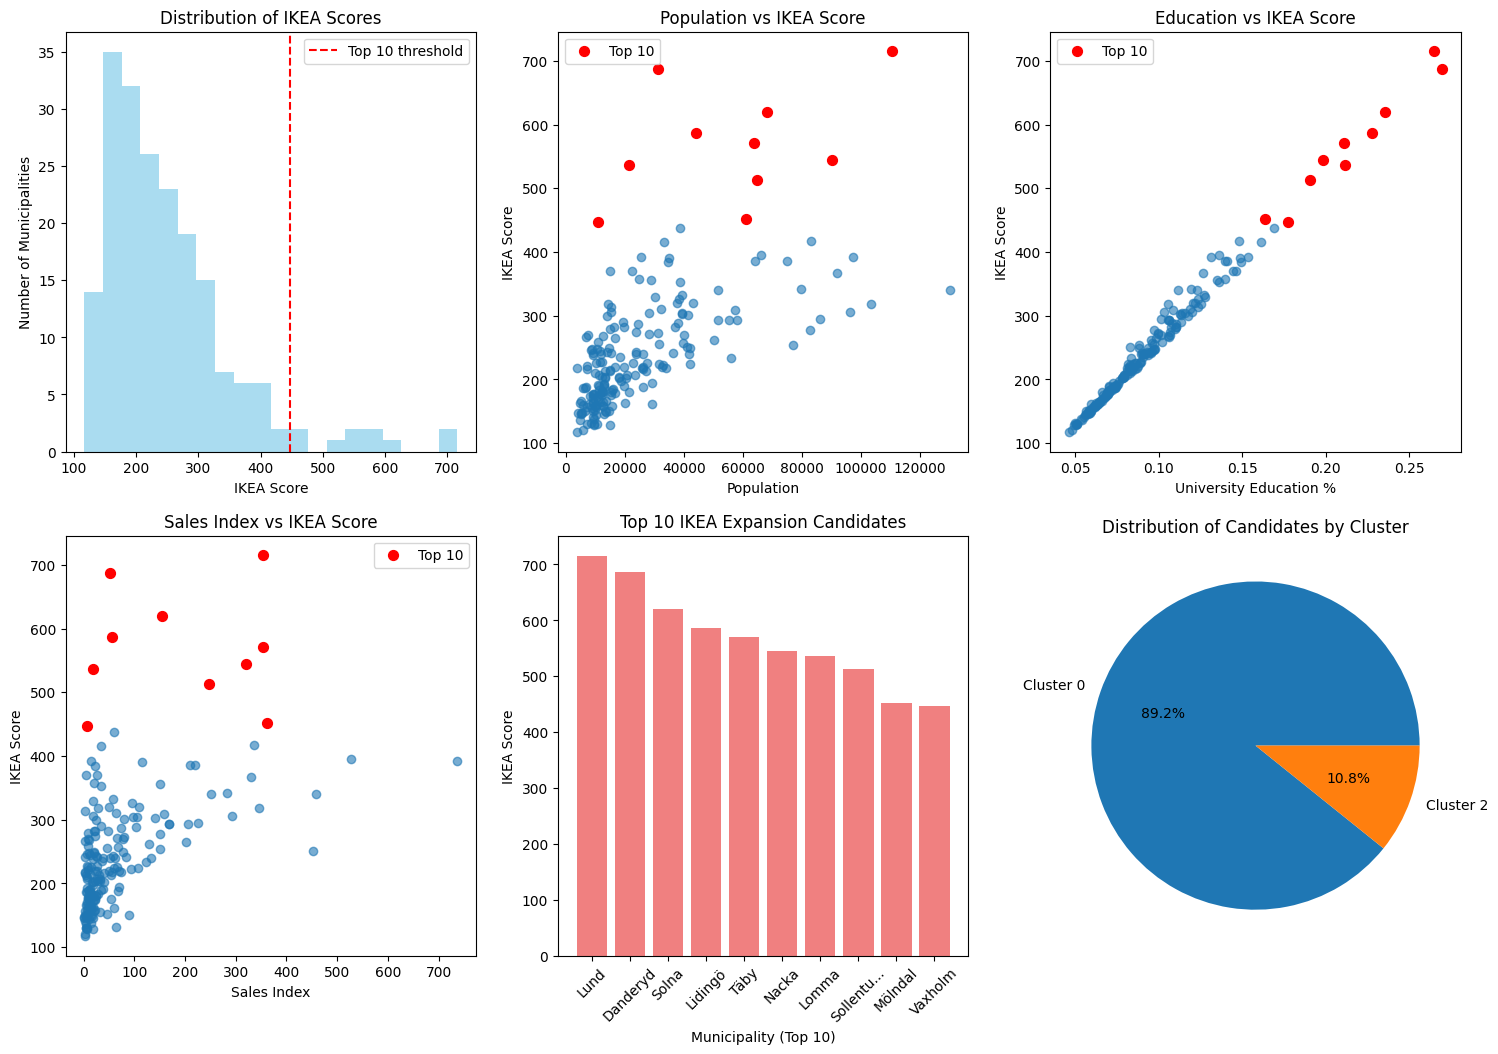

In [126]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Plot 1: Score distribution
axes[0, 0].hist(expansion_candidates['IKEA_Score'], bins=20, alpha=0.7, color='skyblue')
axes[0, 0].axvline(top_candidates['IKEA_Score'].iloc[9], color='red', linestyle='--', 
                       label='Top 10 threshold')
axes[0, 0].set_title('Distribution of IKEA Scores')
axes[0, 0].set_xlabel('IKEA Score')
axes[0, 0].set_ylabel('Number of Municipalities')
axes[0, 0].legend()
# Plot 2: Population vs Score
axes[0, 1].scatter(expansion_candidates['Population'], expansion_candidates['IKEA_Score'], alpha=0.6)
axes[0, 1].scatter(top_candidates.head(10)['Population'], top_candidates.head(10)['IKEA_Score'], 
                       color='red', s=50, label='Top 10')
axes[0, 1].set_xlabel('Population')
axes[0, 1].set_ylabel('IKEA Score')
axes[0, 1].set_title('Population vs IKEA Score')
axes[0, 1].legend()
    
    # Plot 3: University Education vs Score
axes[0, 2].scatter(expansion_candidates['Percent_University'], expansion_candidates['IKEA_Score'], alpha=0.6)
axes[0, 2].scatter(top_candidates.head(10)['Percent_University'], top_candidates.head(10)['IKEA_Score'], 
                       color='red', s=50, label='Top 10')
axes[0, 2].set_xlabel('University Education %')
axes[0, 2].set_ylabel('IKEA Score')
axes[0, 2].set_title('Education vs IKEA Score')
axes[0, 2].legend()    # Plot 4: Sales Index vs Score
axes[1, 0].scatter(expansion_candidates['SalesIndex'], expansion_candidates['IKEA_Score'], alpha=0.6)
axes[1, 0].scatter(top_candidates.head(10)['SalesIndex'], top_candidates.head(10)['IKEA_Score'], 
                       color='red', s=50, label='Top 10')
axes[1, 0].set_xlabel('Sales Index')
axes[1, 0].set_ylabel('IKEA Score')
axes[1, 0].set_title('Sales Index vs IKEA Score')
axes[1, 0].legend()
    
    # Plot 5: Top 10 recommendations comparison
top_10 = top_candidates.head(10)
x_pos = np.arange(len(top_10))
axes[1, 1].bar(x_pos, top_10['IKEA_Score'], color='lightcoral')
axes[1, 1].set_xlabel('Municipality (Top 10)')
axes[1, 1].set_ylabel('IKEA Score')
axes[1, 1].set_title('Top 10 IKEA Expansion Candidates')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels([name[:8] + '...' if len(name) > 8 else name 
                               for name in top_10['Kommun_name']], rotation=45)
    # Plot 6: Cluster distribution of candidates
cluster_counts = expansion_candidates['Cluster'].value_counts()
axes[1, 2].pie(cluster_counts.values, labels=[f'Cluster {i}' for i in cluster_counts.index], 
                   autopct='%1.1f%%')
axes[1, 2].set_title('Distribution of Candidates by Cluster')


In [191]:
print(f"\nIKEA expansion analysis completed!")


IKEA expansion analysis completed!
